# Mathematical Physics: Wave Equation Boundary Condition Classification

Classify string boundary conditions from noisy resonant frequency ratios using quantum kernel and quantum reservoir classifiers.

## Problem, Variables, and Quantum Advantage Context

**Physics problem.** Determine whether a vibrating string is fixed-fixed or fixed-free from its first few resonant frequencies.

**Explicit variables.** `boundary_label` stores the boundary class, `frequency_ratios` are normalized spectral measurements, and `qkc_pred` contains quantum-kernel predictions.

**Quantum advantage context.** Boundary conditions leave structured nonlinear fingerprints in spectral data. Quantum kernels and reservoir features provide compact nonlinear classifiers for this kind of small inverse spectral problem.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "real_examples":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelClassifier,
    QuantumKernelPCA,
    QuantumKernelRegressor,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.reporting import print_section


## Domain simulator

The notebook samples the first four resonant frequencies. Fixed-fixed strings have integer harmonic ratios, while fixed-free strings have odd-integer ratios.

In [2]:
def string_frequency_ratios(boundary_label, *, n_modes=4):
    modes = np.arange(1, n_modes + 1, dtype=float)
    if boundary_label == 0:
        ratios = modes
    else:
        ratios = 2.0 * modes - 1.0
    return ratios / ratios[0]

rng = np.random.default_rng(841)
n_samples = 42
boundary_label = np.asarray([0, 1] * (n_samples // 2), dtype=int)
rng.shuffle(boundary_label)
wave_speed = rng.uniform(0.85, 1.2, size=n_samples)
length = rng.uniform(0.8, 1.3, size=n_samples)
frequency_ratios = np.asarray([string_frequency_ratios(label) for label in boundary_label])
frequency_ratios += rng.normal(0.0, 0.045, size=frequency_ratios.shape)
fundamental = wave_speed / (2.0 * length) * np.where(boundary_label == 0, 1.0, 0.5)
features_raw = np.column_stack([frequency_ratios, fundamental / fundamental.mean()])

x_train, x_test, y_train, y_test = train_test_split(
    features_raw, boundary_label, test_size=0.3, random_state=841, stratify=boundary_label
)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print_section(
    "Dataset",
    [
        ("Problem", "wave equation boundary condition classification"),
        ("Samples", n_samples),
        ("Features", ["f1/f1", "f2/f1", "f3/f1", "f4/f1", "scaled fundamental"]),
        ("Classes", {0: "fixed-fixed", 1: "fixed-free"}),
    ],
)


Dataset
+----------+--------------------------------------------------+
| Metric   | Value                                            |
+----------+--------------------------------------------------+
| Problem  | wave equation boundary condition classification  |
| Samples  | 42                                               |
| Features | [f1/f1, f2/f1, f3/f1, f4/f1, scaled fundamental] |
| Classes  | {0: 'fixed-fixed', 1: 'fixed-free'}              |
+----------+--------------------------------------------------+



## System visualization

A direct plot of the simulated physical or mathematical system before fitting any machine-learning model.

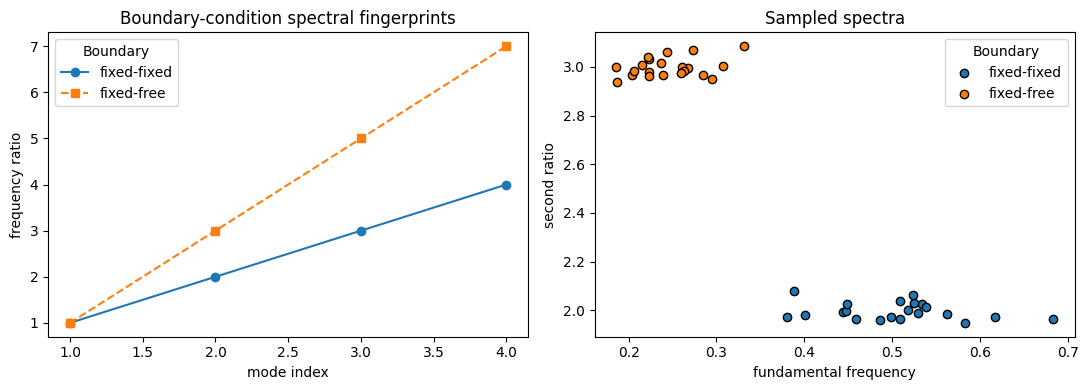

In [3]:
mode_grid = np.arange(1, 5)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mode_grid, string_frequency_ratios(0), "o-", label="fixed-fixed")
axes[0].plot(mode_grid, string_frequency_ratios(1), "s--", label="fixed-free")
axes[0].set_title("Boundary-condition spectral fingerprints")
axes[0].set_xlabel("mode index")
axes[0].set_ylabel("frequency ratio")
axes[0].legend(title="Boundary")
for label, name in [(0, "fixed-fixed"), (1, "fixed-free")]:
    idx = np.where(boundary_label == label)[0]
    axes[1].scatter(fundamental[idx], frequency_ratios[idx, 1], label=name, edgecolor="black")
axes[1].set_title("Sampled spectra")
axes[1].set_xlabel("fundamental frequency")
axes[1].set_ylabel("second ratio")
axes[1].legend(title="Boundary")
plt.tight_layout()
plt.show()


## Package-client classification models

In [4]:
qkc = QuantumKernelClassifier(QuantumKernel(embedding="iqp", seed=841))
qkc.fit(x_train, y_train)
qkc_pred = qkc.predict(x_test)

reservoir = QuantumReservoirClassifier(
    QuantumReservoirFeatures(n_qubits=5, n_layers=2, seed=842),
    c=1.0,
    max_iter=1000,
)
reservoir.fit(x_train, y_train)
reservoir_pred = reservoir.predict(x_test)

logistic = LogisticRegression(max_iter=1000)
logistic.fit(x_train, y_train)
logistic_pred = logistic.predict(x_test)

results = {
    "quantum_kernel_accuracy": accuracy_score(y_test, qkc_pred),
    "quantum_reservoir_accuracy": accuracy_score(y_test, reservoir_pred),
    "logistic_accuracy": accuracy_score(y_test, logistic_pred),
}

print_section(
    "Results",
    [
        ("Quantum kernel accuracy", results["quantum_kernel_accuracy"]),
        ("Quantum reservoir accuracy", results["quantum_reservoir_accuracy"]),
        ("Logistic accuracy", results["logistic_accuracy"]),
    ],
)


Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| Quantum kernel accuracy    | 1        |
| Quantum reservoir accuracy | 0.846154 |
| Logistic accuracy          | 1        |
+----------------------------+----------+



## Plots

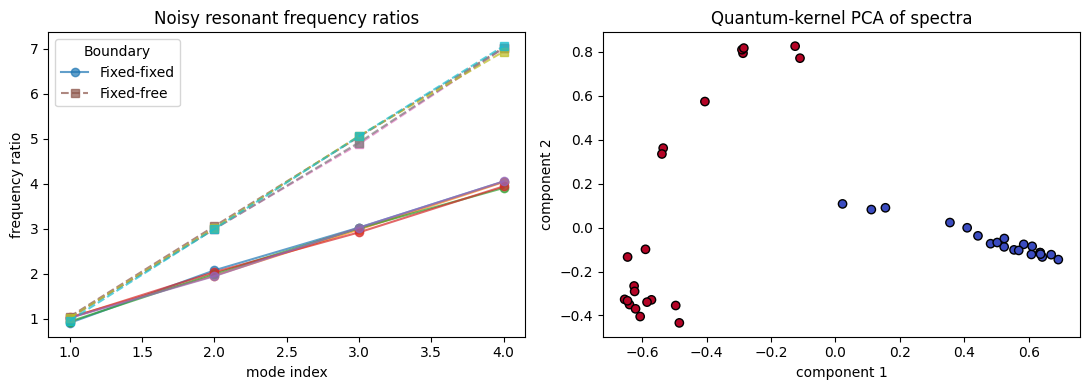

In [5]:
kpca = QuantumKernelPCA(QuantumKernel(embedding="zz", seed=843), n_components=2)
embedding = kpca.fit_transform(scaler.transform(features_raw))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label, name, style in [(0, "Fixed-fixed", "o-"), (1, "Fixed-free", "s--")]:
    idx = np.where(boundary_label == label)[0][:5]
    for pos, sample_idx in enumerate(idx):
        axes[0].plot(np.arange(1, 5), frequency_ratios[sample_idx], style, alpha=0.7, label=name if pos == 0 else None)
axes[0].set_title("Noisy resonant frequency ratios")
axes[0].set_xlabel("mode index")
axes[0].set_ylabel("frequency ratio")
axes[0].legend(title="Boundary")

scatter = axes[1].scatter(embedding[:, 0], embedding[:, 1], c=boundary_label, cmap="coolwarm", edgecolor="black")
axes[1].set_title("Quantum-kernel PCA of spectra")
axes[1].set_xlabel("component 1")
axes[1].set_ylabel("component 2")
plt.tight_layout()
plt.show()


## Validation block

In [6]:
validation = {
    "dataset": {
        "problem": "wave_equation_boundary_condition_classification",
        "n_train": int(len(y_train)),
        "n_test": int(len(y_test)),
        "feature_count": int(x_train.shape[1]),
    },
    "results": results,
    "sample_predictions": [
        {"actual_boundary": int(a), "quantum_kernel_boundary": int(p), "reservoir_boundary": int(r)}
        for a, p, r in zip(y_test[:6], qkc_pred[:6], reservoir_pred[:6])
    ],
    "passed": bool(
        np.isfinite(qkc_pred).all()
        and results["quantum_kernel_accuracy"] >= 0.85
        and results["quantum_reservoir_accuracy"] >= 0.70
    ),
}

print("Validation")
print_section("Dataset", validation["dataset"].items())
print_section("Results", validation["results"].items())
print_section("Sample predictions", validation["sample_predictions"][:5])
print_section("Passed", [("passed", validation["passed"])])


Validation
Dataset
+---------------+-------------------------------------------------+
| Metric        | Value                                           |
+---------------+-------------------------------------------------+
| problem       | wave_equation_boundary_condition_classification |
| n_train       | 29                                              |
| n_test        | 13                                              |
| feature_count | 5                                               |
+---------------+-------------------------------------------------+

Results
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| quantum_kernel_accuracy    | 1        |
| quantum_reservoir_accuracy | 0.846154 |
| logistic_accuracy          | 1        |
+----------------------------+----------+

Sample predictions
+-----------------+-------------------------+--------------------+
| actual_boundary | quantum_kernel_boundary | r